In [ ]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 23.6 MB/s eta 0:00:00


In [ ]:
#Semesta Pembicara
# ntu = np.arange(start, stop, step)
ntu = np.arange(0, 3001, 1)

In [ ]:
#Derajat Keanggotaan
# Kondisi ketika jernih, menggunakan trampf (menggunakan keanggotaan kurva trapesium)
# fuzzynya 0 ke-1 batas atas, 0 ke-2 batas bawah kiri dan akan semakin naik batas puncaknya ada di 0-40 (ntr di sesuaikan journal)
jernih = fuzzy.trapmf(ntu, [0, 0, 25, 50])

# Keruh: 40 hingga 600
# batas puncak ketika kondisi fuzzynya 1 ada di 100-300
keruh = fuzzy.trapmf(ntu, [25, 100, 200, 400])

# Sangat Keruh: 300 hingga 1000
# 1000 ke-1 itu batas kanan atas dan 1000 ke-2 batas kanan bawah, golongan sangat keruh
# batas puncak ketika kondisi di 1000
kotor = fuzzy.trapmf(ntu, [200, 400, 3000, 3000])

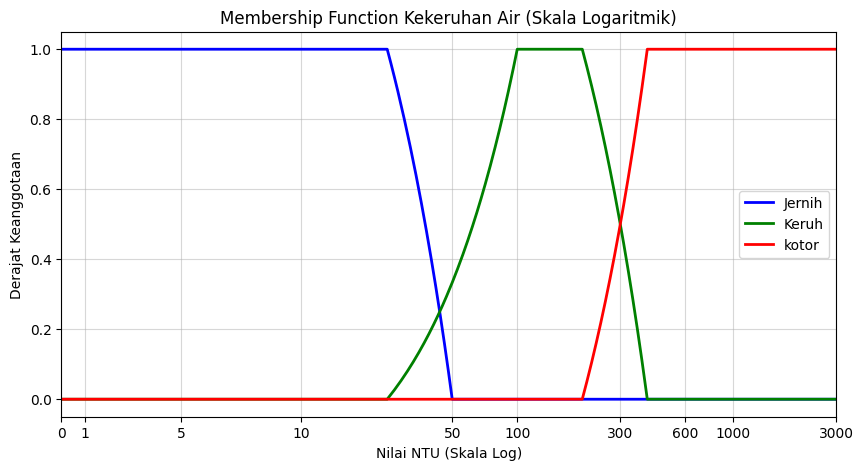

In [ ]:
#Kurva
plt.figure(figsize=(10, 5))
plt.plot(ntu, jernih, 'b', linewidth=2, label='Jernih')
plt.plot(ntu, keruh, 'g', linewidth=2, label='Keruh')
plt.plot(ntu, kotor, 'r', linewidth=2, label='kotor')
plt.xscale('symlog', linthresh=10)
plt.title('Membership Function Kekeruhan Air (Skala Logaritmik)')
plt.xlabel('Nilai NTU (Skala Log)')
plt.ylabel('Derajat Keanggotaan')
plt.xlim(0, 3000)

plt.xticks([0, 1, 5, 10, 50, 100, 300, 600, 1000, 3000],
           ['0', '1', '5', '10', '50', '100', '300', '600', '1000', '3000'])

plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

In [ ]:
#fuzzifikasi:
# Input contoh sensor
input_sensor = 25

# Proses Fuzzifikasi
derajat_jernih = fuzzy.interp_membership(ntu, jernih, input_sensor)
derajat_keruh = fuzzy.interp_membership(ntu, keruh, input_sensor)
derajat_sangat_keruh = fuzzy.interp_membership(ntu, kotor, input_sensor)

print(f"Hasil Fuzzifikasi untuk {input_sensor} NTU:")
print(f"Derajat Jernih: {derajat_jernih:.2f}")
print(f"Derajat Keruh: {derajat_keruh:.2f}")
print(f"Derajat Kotor: {derajat_sangat_keruh:.2f}")

Hasil Fuzzifikasi untuk 29 NTU:
Derajat Jernih: 0.84
Derajat Keruh: 0.05
Derajat Kotor: 0.00


In [ ]:
# Tahap Rule Base (Menentukan bobot tiap aturan)
# w = weight (bobot), z = output constant

# Rule 1: Jika Jernih
w1 = derajat_jernih
z1 = 1

# Rule 2: Jika Keruh
w2 = derajat_keruh
z2 = 2

# Rule 3: Jika Sangat Keruh
w3 = derajat_sangat_keruh
z3 = 3

print(f"Aturan 1 (Jernih) terpicu: {w1:.2f}")
print(f"Aturan 2 (Keruh) terpicu: {w2:.2f}")
print(f"Aturan 3 (Sangat Keruh) terpicu: {w3:.2f}")

Aturan 1 (Jernih) terpicu: 0.84
Aturan 2 (Keruh) terpicu: 0.05
Aturan 3 (Sangat Keruh) terpicu: 0.00


In [ ]:
# Tahap Defuzzifikasi
pembilang = (w1 * z1) + (w2 * z2) + (w3 * z3)
penyebut = w1 + w2 + w3

if penyebut != 0:
    z_akhir = pembilang / penyebut
else:
    z_akhir = 0

print(f"Hasil Defuzzifikasi (Z): {z_akhir:.2f}")

#proses klasifikasi
if z_akhir <= 1.5:
    print("Klasifikasi Akhir: AIR JERNIH")
elif 1.5 < z_akhir <= 2.5:
    print("Klasifikasi Akhir: AIR KERUH")
else:
    print("Klasifikasi Akhir: AIR SANGAT KERUH")

Hasil Defuzzifikasi (Z): 1.06
Klasifikasi Akhir: AIR JERNIH
